In [1]:
#Libraries for Machine Learning
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
fall = pd.read_csv('Dataset/fall.csv', header = None)
non_fall = pd.read_csv('Dataset/nf.csv', header = None)
rest = pd.read_csv('Dataset/rest.csv', header = None)

fall[0] = 1
non_fall[0] = 2
rest[0] = 3

fin = pd.concat([fall,non_fall,rest])

In [3]:
x = fin.iloc[:,1:].values
y = fin.iloc[:,0].values

In [4]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,random_state = 0)

In [5]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [6]:
from matplotlib.colors import ListedColormap

def LDA_Plot(x_val, y_val, x_test, y_test, func, step = 0.01, title = "Title", dpi = 800):
    plt.figure(dpi = dpi)
    
    x_set, y_set = x_val, y_val
    #To get a meshgrid for plotting on contour
    x1, x2 = np.meshgrid( np.arange(start = x_set[:,0].min() - 1, stop = x_set[:,0].max() + 1, step = step),
                          np.arange(start = x_set[:,1].min() - 1, stop = x_set[:,1].max() + 1, step = step))
    #Plotting on the contour
    Z = func(np.array([x1.ravel(), x2.ravel()]).T).reshape(x1.shape)
    plt.contourf(x1, x2, Z,
                 cmap = ListedColormap(('red', 'green', 'blue')), alpha = 0.75)
    #Limiting the plot to max & min units of x1 & x2
    plt.xlim(x1.min(), x1.max())
    plt.ylim(x2.min(), x2.max())
    plt.title("Decision Boundary - " + title)
    plt.savefig("Snips\\Decision Boundary - " + title)
    plt.show()
    
    plt.figure(dpi = dpi)
    
    plt.contourf(x1, x2, Z,
                 cmap = ListedColormap(('red', 'green', 'blue')), alpha = 0.75)
    #Limiting the plot to max & min units of x1 & x2
    plt.xlim(x1.min(), x1.max())
    plt.ylim(x2.min(), x2.max())
    #Scatter plot of y_val
    for i, j in enumerate(np.unique(y_test)):
        plt.scatter(x_test[y_test==j, 0], x_test[y_test==j, 1], 
                    color = ListedColormap(("#8B0000", 'green', '#0000A0'))(i), label= j, s = 0.5) #Dark Red & Blue for clear visibility
    plt.title( "Scatter Plot on Decision Boundary - " + title)
    plt.legend()
    plt.savefig("Snips\\Scatter Plot on Decision Boundary - " + title)
    plt.show()

## Data Visualisation

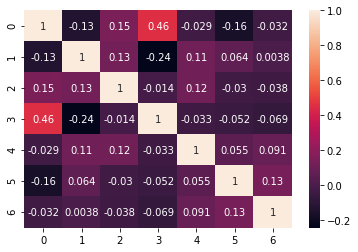

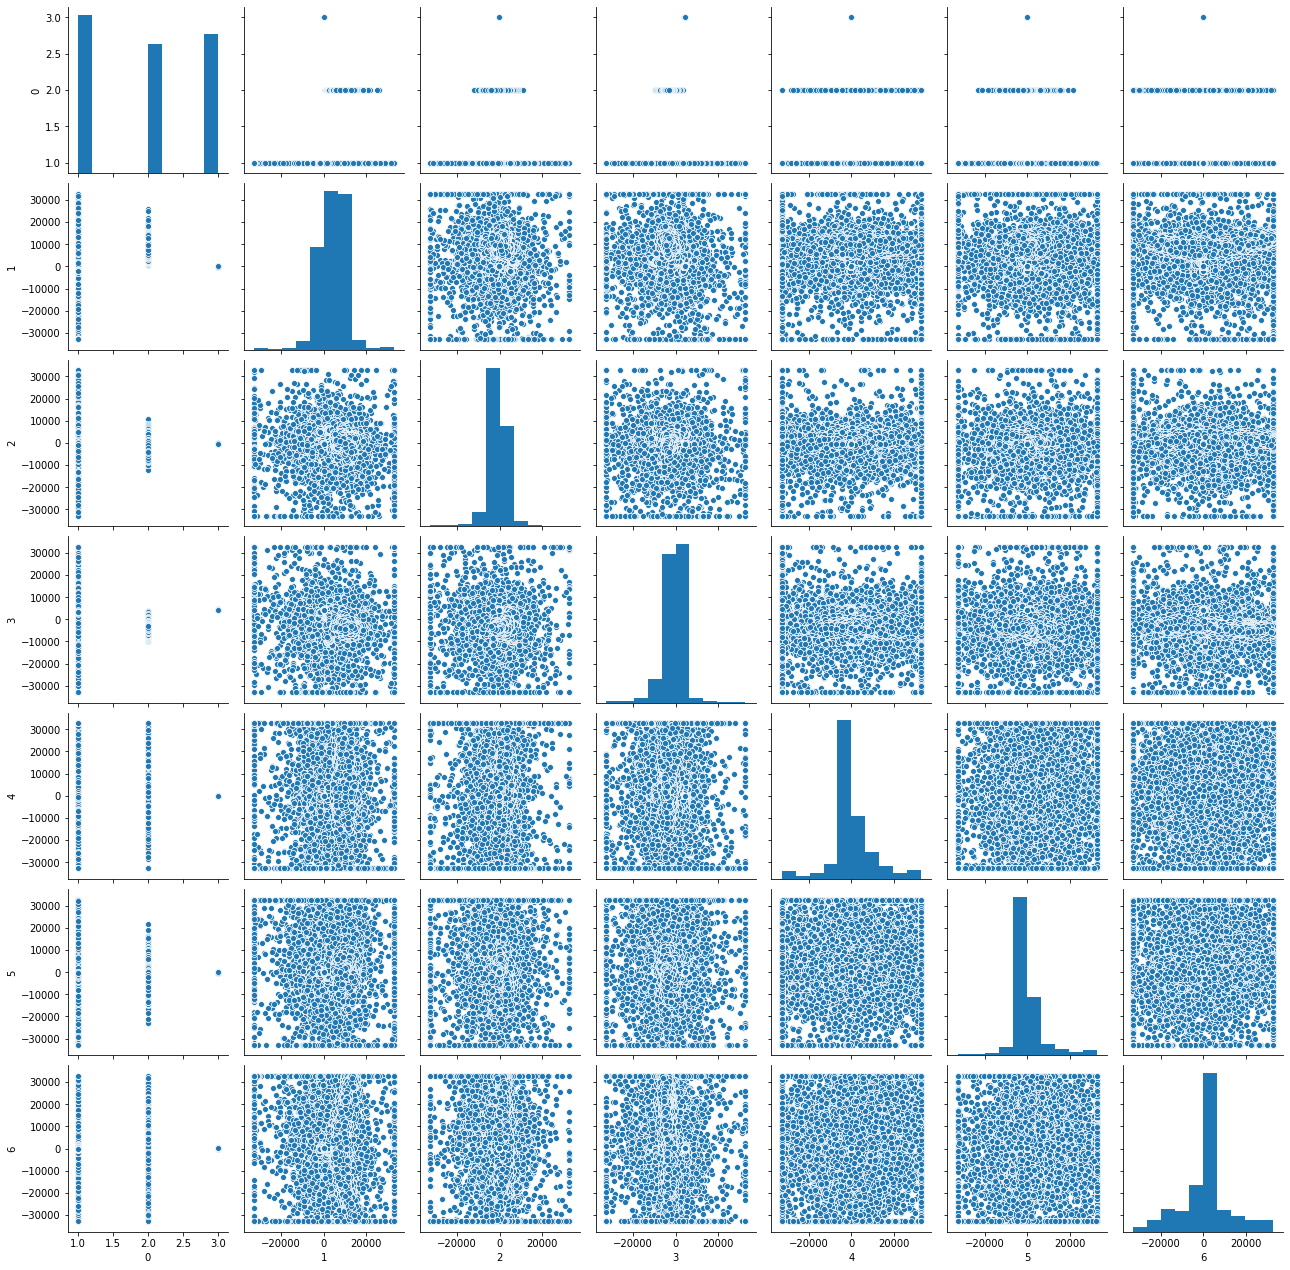

In [8]:
import seaborn as sns

#Heatmap of the data
correlation = fin.corr()
sns.heatmap(correlation, annot=True)
plt.show()

#Pairplotting of all the parameters
sns.pairplot(fin)
plt.show()

## K Nearest Neighbors

In [8]:
from sklearn.neighbors import KNeighborsClassifier
classifier_k = KNeighborsClassifier(n_neighbors=10, metric='minkowski', p=2)
classifier_k.fit(x_train, y_train)

y_pred = classifier_k.predict(x_train)

In [9]:
#Confusion Matrix & Accuracy for evaluating the model for training data

from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
cm = confusion_matrix(y_train, y_pred)
print("Confusion Matrix (Train Data): \n", cm)

accuracy = accuracy_score(y_train, y_pred)
print("Accuracy (Train Data): {:.2f} %".format(accuracy*100))

Confusion Matrix (Train Data): 
 [[9526  289    5]
 [ 147 7852    0]
 [   0    0 8551]]
Accuracy (Train Data): 98.33 %


In [10]:
sen = np.array([ cm[0][0]/sum(cm[:, 0]), cm[1][1]/sum(cm[:, 1]), cm[2][2]/sum(cm[:, 2]) ])
print("Sensitivity of Fall for Train Data: ", sen[0])
print("Sensitivity of Non-Fall for Train Data: ", sen[1])
print("Sensitivity of Rest for Train Data: ", sen[2])
print("Sensitivity of Train Data: ", sen.mean()*100, "%")

spec = np.array([ (cm[1][1] + cm[2][2])/(sum(cm[:, 1]) + sum(cm[:, 2])), 
                  (cm[0][0] + cm[2][2])/(sum(cm[:, 0]) + sum(cm[:, 2])),
                  (cm[0][0] + cm[1][1])/(sum(cm[:, 0]) + sum(cm[:, 1]))
                ])
print("Specificity of Fall for Train Data: ", spec[0] )
print("Specificity of Non-Fall for Train Data: ",  spec[1] )
print("Specificity of Rest for Train Data: ",  spec[2])
print("Specificity of Train Data", spec.mean()*100, "%")

Sensitivity of Fall for Train Data:  0.9848030600640959
Sensitivity of Non-Fall for Train Data:  0.964500675592679
Sensitivity of Rest for Train Data:  0.9994156147732586
Sensitivity of Train Data:  98.29064501433446 %
Specificity of Fall for Train Data:  0.9823920464754148
Specificity of Non-Fall for Train Data:  0.9916616380492622
Specificity of Rest for Train Data:  0.9755248680812844
Specificity of Train Data 98.31928508686538 %


In [11]:
# Confusion Matrix & Accuracy for evaluating the model for test data

y_pred = classifier_k.predict(x_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (Test Data): \n", cm)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy (Test Data): {:.2f} %".format(accuracy*100))

Confusion Matrix (Test Data): 
 [[3106  123    8]
 [  58 2607    0]
 [   0    0 2889]]
Accuracy (Test Data): 97.85 %


In [12]:
sen = np.array([ cm[0][0]/sum(cm[:, 0]), cm[1][1]/sum(cm[:, 1]), cm[2][2]/sum(cm[:, 2]) ])
print("Sensitivity of Fall for Test Data: ", sen[0])
print("Sensitivity of Non-Fall for Test Data: ", sen[1])
print("Sensitivity of Rest for Test Data: ", sen[2])
print("Sensitivity of Test Data: ", sen.mean()*100, "%")

spec = np.array([ (cm[1][1] + cm[2][2])/(sum(cm[:, 1]) + sum(cm[:, 2])), 
                  (cm[0][0] + cm[2][2])/(sum(cm[:, 0]) + sum(cm[:, 2])),
                  (cm[0][0] + cm[1][1])/(sum(cm[:, 0]) + sum(cm[:, 1]))
                ])
print("Specificity of Fall for Test Data: ", spec[0] )
print("Specificity of Non-Fall for Test Data: ",  spec[1] )
print("Specificity of Rest for Test Data: ",  spec[2])
print("Specificity of Test Data", spec.mean()*100, "%")

Sensitivity of Fall for Test Data:  0.9816687737041719
Sensitivity of Non-Fall for Test Data:  0.954945054945055
Sensitivity of Rest for Test Data:  0.9972385226095961
Sensitivity of Test Data:  97.7950783752941 %
Specificity of Fall for Test Data:  0.9767193886618092
Specificity of Non-Fall for Test Data:  0.9891107078039928
Specificity of Rest for Test Data:  0.9692908042076688
Specificity of Test Data 97.83736335578236 %


In [29]:
# 10_Fold CV accuracy

from sklearn.model_selection import cross_val_score

accuracies = cross_val_score(estimator=classifier_k, X=x_train, y=y_train, cv=10, n_jobs=-1)
print("Mean of Train Accuracies: {:.2f} %".format(accuracies.mean()*100))
print("Std of Train Accuracies: ", accuracies.std())

accuracies = cross_val_score(estimator=classifier_k, X=x_test, y=y_test, cv=10)
print("Mean of Test Accuracies: {:.2f} %".format(accuracies.mean()*100))
print("Std of Test Accuracies: ", accuracies.std())

Mean of Train Accuracies: 97.94 %
Std of Train Accuracies:  0.0020894921977938343
Mean of Test Accuracies: 97.29 %
Std of Test Accuracies:  0.00569752561450334


In [30]:
# Choosing k, such that 98% of the variance is reatined.
# But, here even for k = 1, 100% variance is retained. So, for better data visualisation k=2 is chosen
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
lda = LDA(n_components=2)
# Transforming z_train & z_test using the new reduced dimension vector (U_reduce)
z_train = lda.fit_transform(x_train, y_train)
z_test = lda.transform(x_test)

In [31]:
# Analysing the SVM model fit with z_train
classifier_z = KNeighborsClassifier(n_neighbors=10, metric='minkowski', p=2)
classifier_z.fit(z_train, y_train)
y_z_pred = classifier_z.predict(z_train)

In [32]:
cm = confusion_matrix(y_z_pred, y_train)
print("Confustion Matrix (Z-Test Data): \n", cm)
accuracy = accuracy_score(y_train, y_z_pred)
print("Accuracy (Z-Train Data): {:.2f} %".format(accuracy*100))

Confustion Matrix (Z-Test Data): 
 [[8990  668    0]
 [ 816 7331    0]
 [  14    0 8551]]
Accuracy (Z-Train Data): 94.32 %


In [33]:
y_z_pred = classifier_z.predict(z_test)

cm = confusion_matrix(y_test, y_z_pred)
print("Confusion Matrix (Test Data): \n", cm)
accuracy = accuracy_score(y_test, y_z_pred)
print("Accuracy (Z-Test Data): {:.2f} %".format(accuracy*100))

Confusion Matrix (Test Data): 
 [[2897  328   12]
 [ 254 2411    0]
 [   0    0 2889]]
Accuracy (Z-Test Data): 93.24 %


In [34]:
# 10_Fold CV accuracy

accuracies = cross_val_score(estimator=classifier_z, X=z_train, y=y_train, cv=10, n_jobs=-1)
print("Mean of Train Accuracies: {:.2f} %".format(accuracies.mean()*100))
print("Std of the Train Accuracies: ", accuracies.std())

accuracies = cross_val_score(estimator=classifier_z, X=z_test, y=y_test, cv=10)
print("Mean of Test Accuracies: {:.2f} %".format(accuracies.mean()*100))
print("Std of the Test Accuracies: ", accuracies.std())

Mean of Train Accuracies: 93.12 %
Std of the Train Accuracies:  0.005384907091391746
Mean of Test Accuracies: 92.90 %
Std of the Test Accuracies:  0.008711200287936321


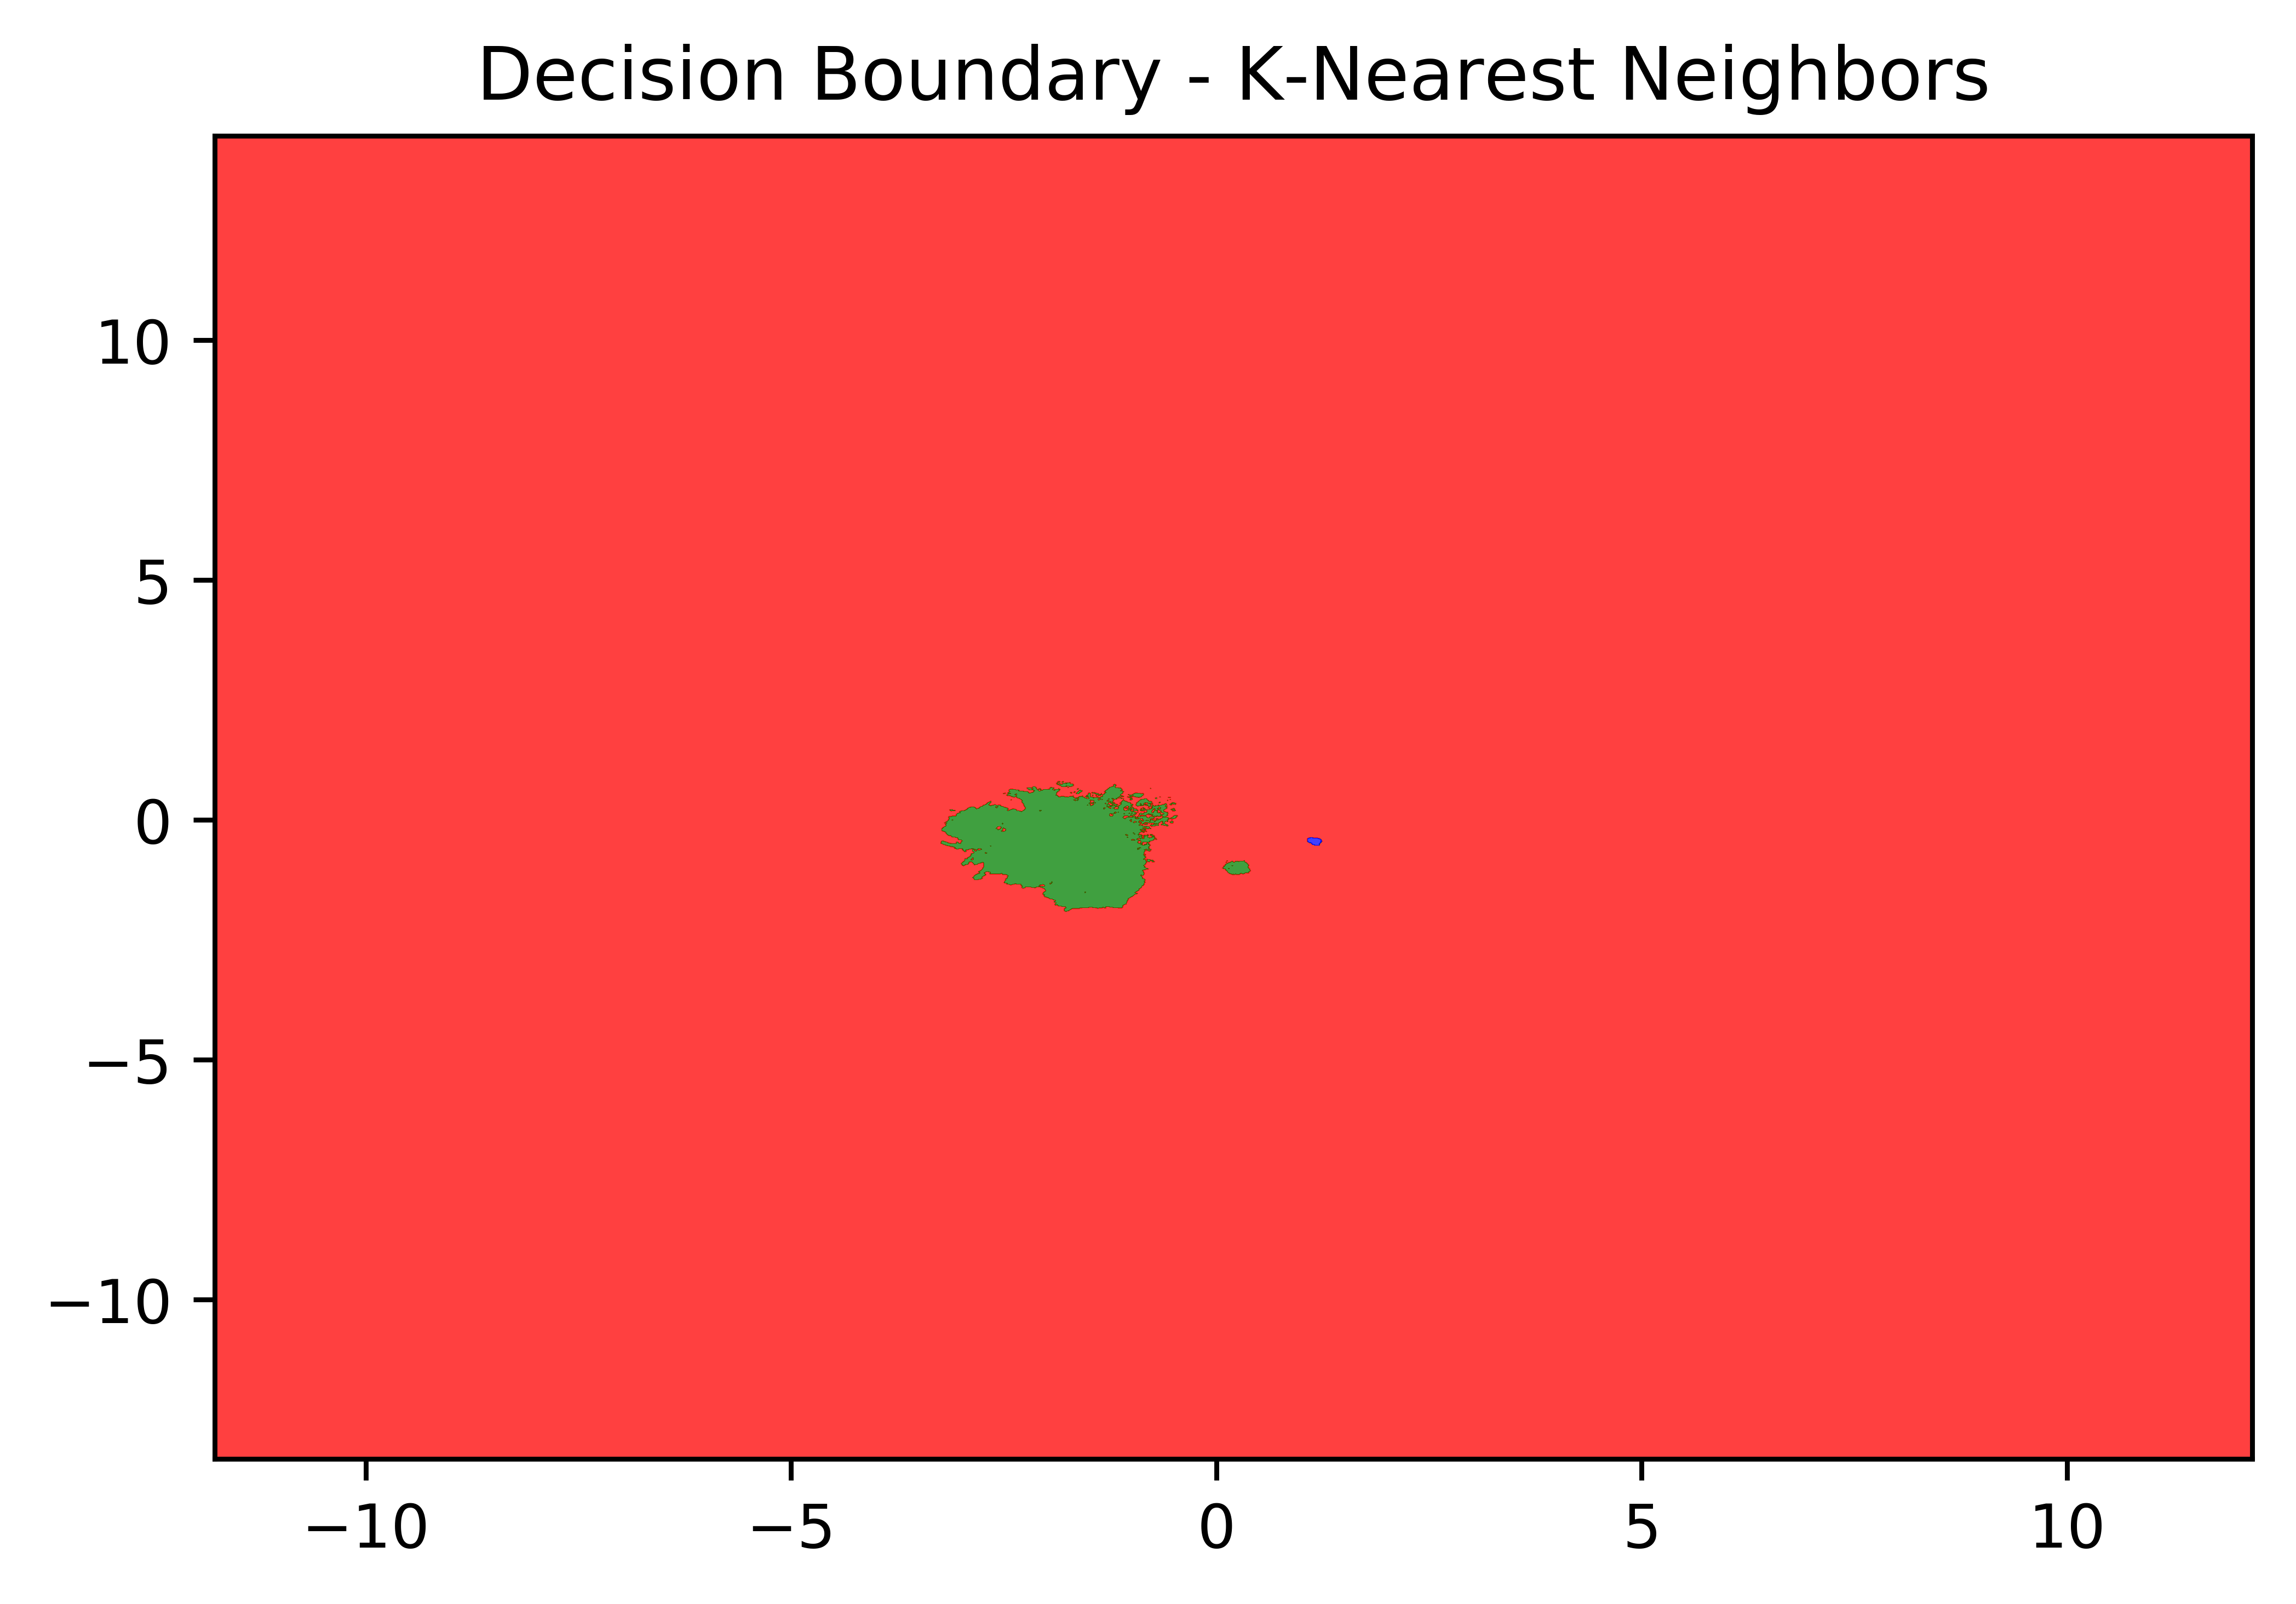

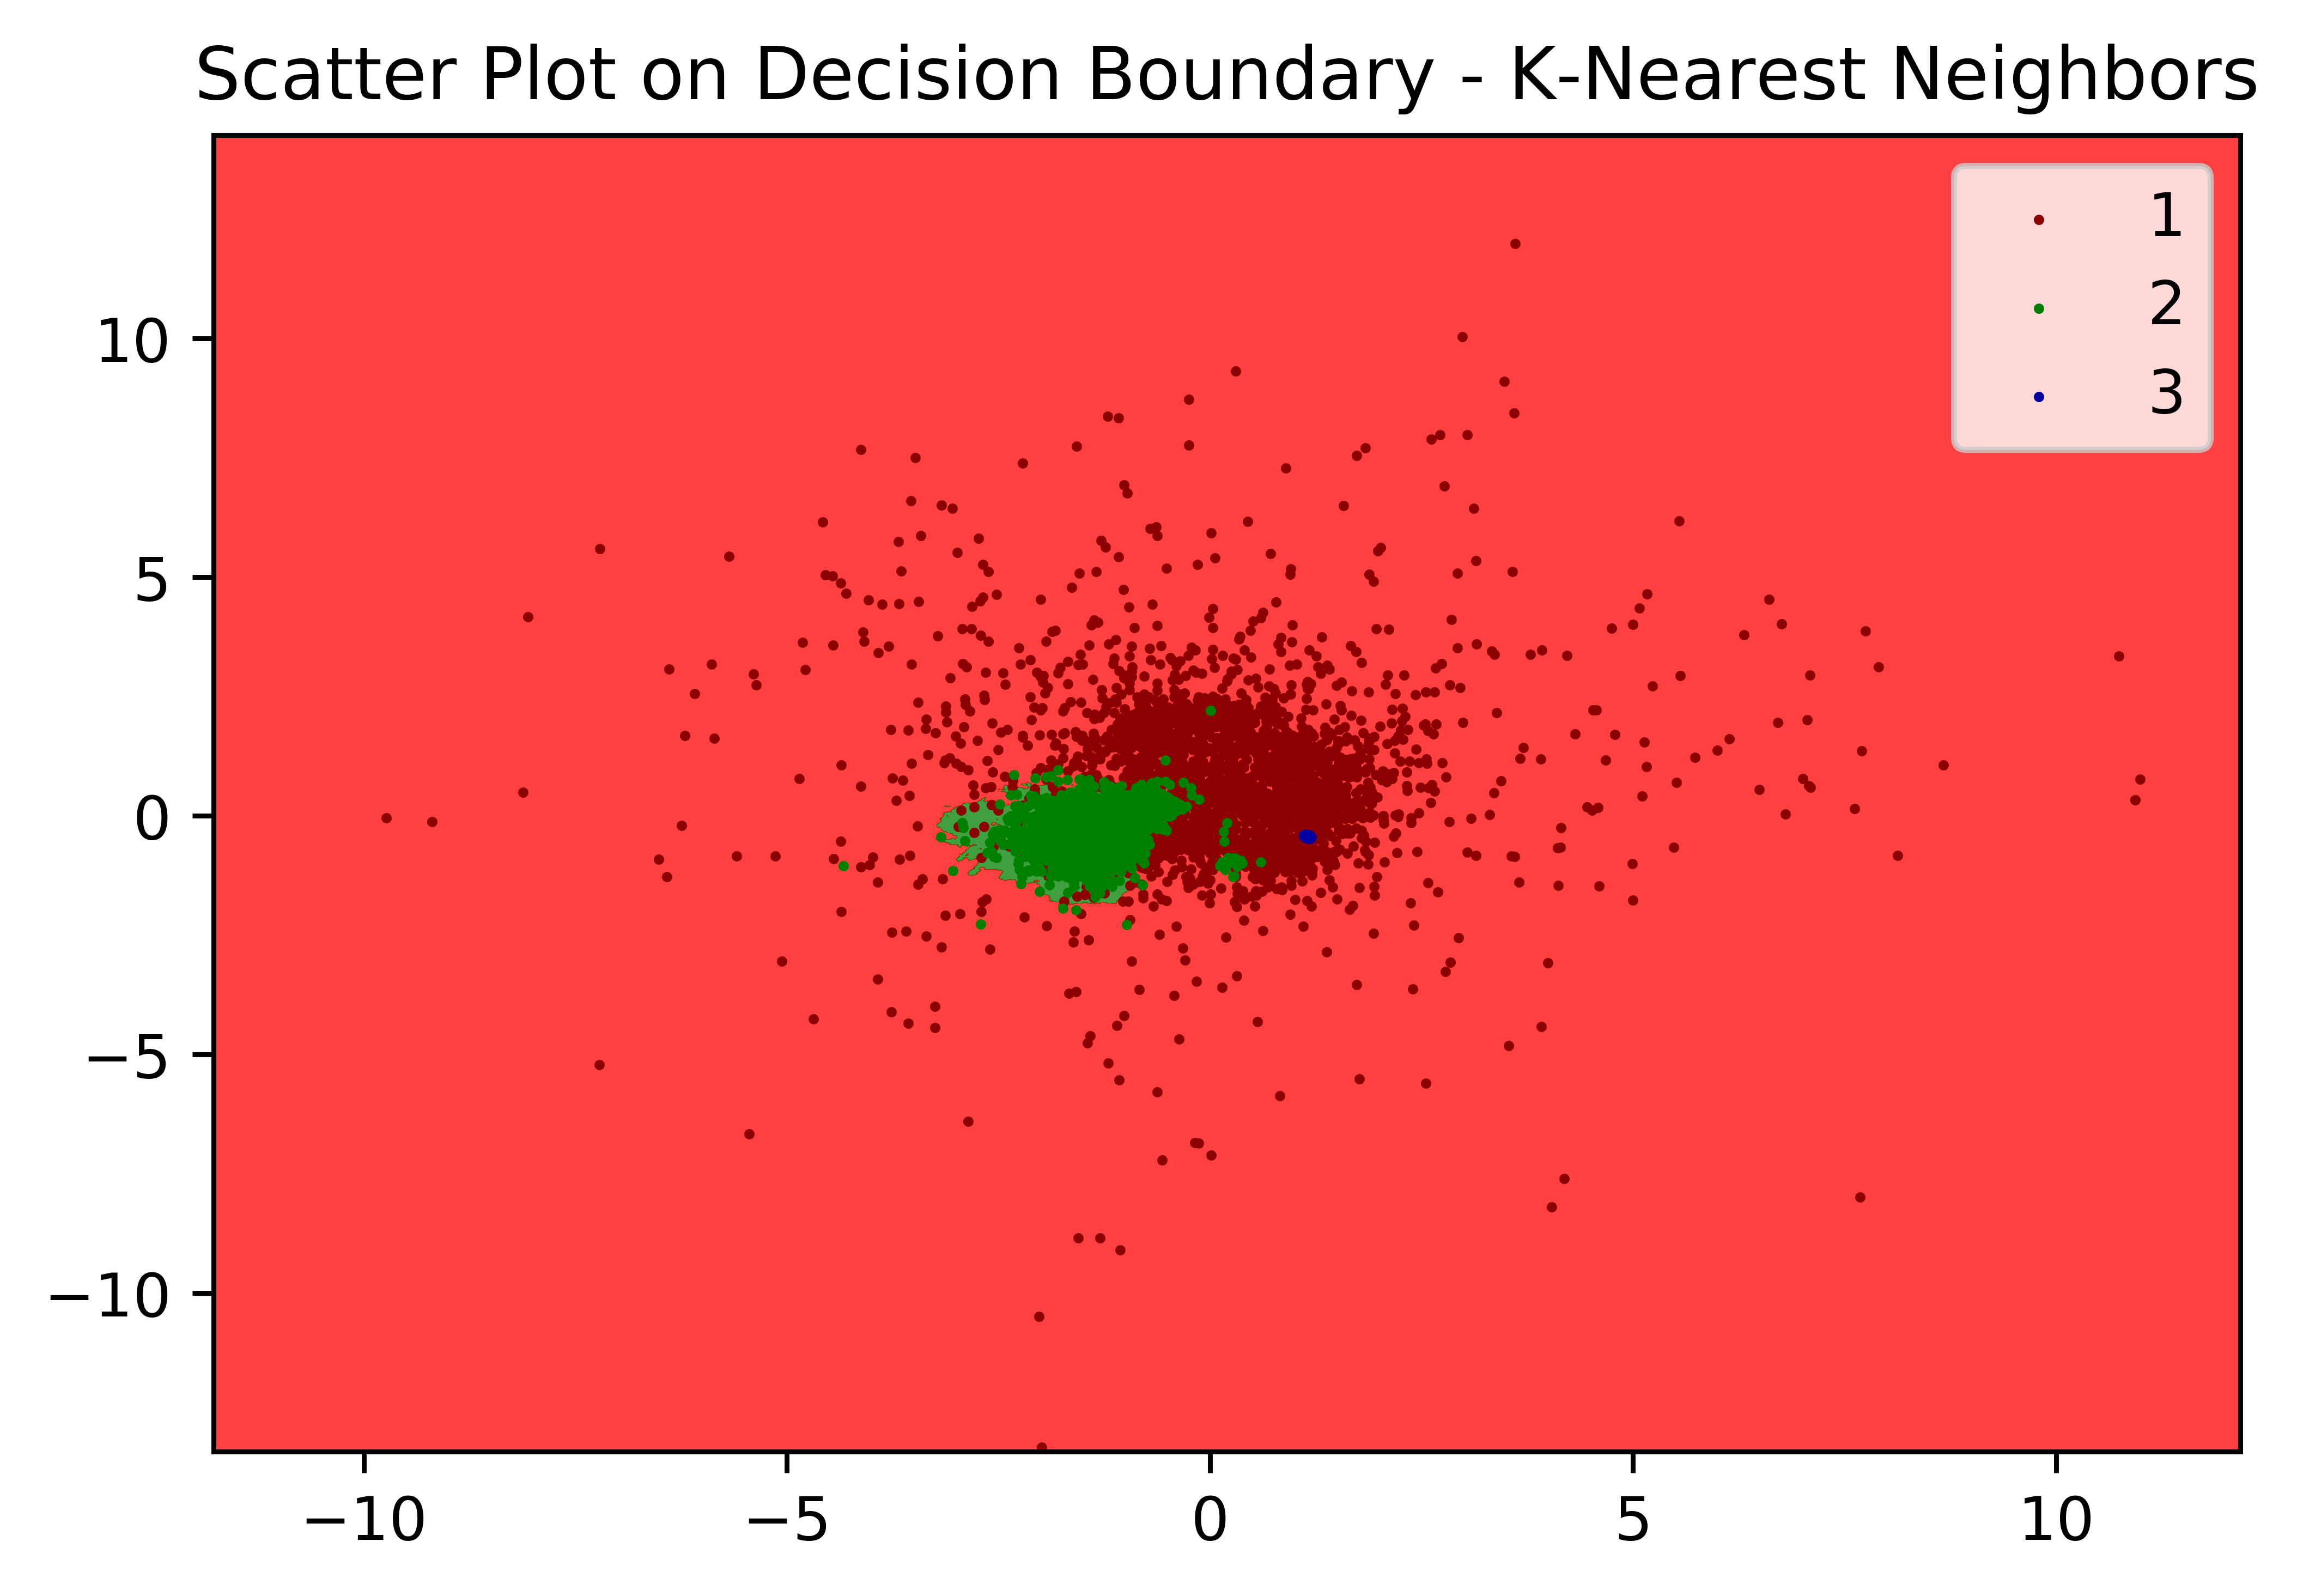

In [35]:
LDA_Plot(z_train, y_train, z_test, y_test, func = classifier_z.predict ,title = "K-Nearest Neighbors")

## XGBoost

In [14]:
from xgboost import XGBClassifier
classifier_xg = XGBClassifier(n_estimators = 600, n_jobs = 1)
classifier_xg.fit(x_train, y_train)

y_pred = classifier_xg.predict(x_train)

In [24]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
cm = confusion_matrix(y_train, y_pred)
print("Confusion Matrix (Train Data): \n", cm)

accuracy = accuracy_score(y_train, y_pred)
print("Accuracy (Train Data): {:.2f} %".format(accuracy*100))

Confusion Matrix (Train Data): 
 [[9672  148    0]
 [  90 7909    0]
 [   0    0 8551]]
Accuracy (Train Data): 99.10 %


In [25]:
sen = np.array([ cm[0][0]/sum(cm[:, 0]), cm[1][1]/sum(cm[:, 1]), cm[2][2]/sum(cm[:, 2]) ])
print("Sensitivity of Fall for Train Data: ", sen[0])
print("Sensitivity of Non-Fall for Train Data: ", sen[1])
print("Sensitivity of Rest for Train Data: ", sen[2])
print("Sensitivity of Train Data: ", sen.mean()*100, "%")

spec = np.array([ (cm[1][1] + cm[2][2])/(sum(cm[:, 1]) + sum(cm[:, 2])), 
                  (cm[0][0] + cm[2][2])/(sum(cm[:, 0]) + sum(cm[:, 2])),
                  (cm[0][0] + cm[1][1])/(sum(cm[:, 0]) + sum(cm[:, 1]))
                ])
print("Specificity of Fall for Train Data: ", spec[0] )
print("Specificity of Non-Fall for Train Data: ",  spec[1] )
print("Specificity of Rest for Train Data: ",  spec[2])
print("Specificity of Train Data", spec.mean()*100, "%")

Sensitivity of Fall for Train Data:  0.990780577750461
Sensitivity of Non-Fall for Train Data:  0.9816308799801415
Sensitivity of Rest for Train Data:  1.0
Sensitivity of Train Data:  99.08038192435342 %
Specificity of Fall for Train Data:  0.9910886319845857
Specificity of Non-Fall for Train Data:  0.9950854584175176
Specificity of Rest for Train Data:  0.9866434704528874
Specificity of Train Data 99.09391869516635 %


In [26]:
# Confusion Matrix & Accuracy for evaluating the model for test data

y_pred = classifier_k.predict(x_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (Test Data): \n", cm)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy (Test Data): {:.2f} %".format(accuracy*100))

Confusion Matrix (Test Data): 
 [[3106  123    8]
 [  58 2607    0]
 [   0    0 2889]]
Accuracy (Test Data): 97.85 %


In [27]:
sen = np.array([ cm[0][0]/sum(cm[:, 0]), cm[1][1]/sum(cm[:, 1]), cm[2][2]/sum(cm[:, 2]) ])
print("Sensitivity of Fall for Test Data: ", sen[0])
print("Sensitivity of Non-Fall for Test Data: ", sen[1])
print("Sensitivity of Rest for Test Data: ", sen[2])
print("Sensitivity of Test Data: ", sen.mean()*100, "%")

spec = np.array([ (cm[1][1] + cm[2][2])/(sum(cm[:, 1]) + sum(cm[:, 2])), 
                  (cm[0][0] + cm[2][2])/(sum(cm[:, 0]) + sum(cm[:, 2])),
                  (cm[0][0] + cm[1][1])/(sum(cm[:, 0]) + sum(cm[:, 1]))
                ])
print("Specificity of Fall for Test Data: ", spec[0] )
print("Specificity of Non-Fall for Test Data: ",  spec[1] )
print("Specificity of Rest for Test Data: ",  spec[2])
print("Specificity of Test Data", spec.mean()*100, "%")

Sensitivity of Fall for Test Data:  0.9816687737041719
Sensitivity of Non-Fall for Test Data:  0.954945054945055
Sensitivity of Rest for Test Data:  0.9972385226095961
Sensitivity of Test Data:  97.7950783752941 %
Specificity of Fall for Test Data:  0.9767193886618092
Specificity of Non-Fall for Test Data:  0.9891107078039928
Specificity of Rest for Test Data:  0.9692908042076688
Specificity of Test Data 97.83736335578236 %


In [28]:
from sklearn.model_selection import cross_val_score

accuracies = cross_val_score(estimator=classifier_xg, X=x_train, y=y_train, cv=10, n_jobs=-1)
print("Mean of Train Accuracies: {:.2f} %".format(accuracies.mean()*100))
print("Std of Train Accuracies: ", accuracies.std())

accuracies = cross_val_score(estimator=classifier_xg, X=x_test, y=y_test, cv=10, n_jobs = -1)
print("Mean of Test Accuracies: {:.2f} %".format(accuracies.mean()*100))
print("Std of Test Accuracies: ", accuracies.std())

Mean of Train Accuracies: 98.17 %
Std of Train Accuracies:  0.0026911179369298777
Mean of Test Accuracies: 97.87 %
Std of Test Accuracies:  0.005635960894433209


In [23]:
# Choosing k, such that 98% of the variance is reatined.
# But, here even for k = 1, 100% variance is retained. So, for better data visualisation k=2 is chosen

lda = LDA(n_components=2)
# Transforming z_train & z_test using the new reduced dimension vector (U_reduce)
z_train = lda.fit_transform(x_train, y_train)
z_test = lda.transform(x_test)

In [37]:
# Analysing the SVM model fit with z_train
classifier_z = XGBClassifier(n_estimators = 500, n_jobs = 1)
classifier_z.fit(z_train, y_train)
y_z_pred = classifier_z.predict(z_train)

In [38]:
cm = confusion_matrix(y_z_pred, y_train)
print("Confustion Matrix (Z-Test Data): \n", cm)
accuracy = accuracy_score(y_train, y_z_pred)
print("Accuracy (Z-Train Data): {:.2f} %".format(accuracy*100))

Confustion Matrix (Z-Test Data): 
 [[8764  366    0]
 [1053 7633    0]
 [   3    0 8551]]
Accuracy (Z-Train Data): 94.61 %


In [39]:
y_z_pred = classifier_z.predict(z_test)

cm = confusion_matrix(y_test, y_z_pred)
print("Confusion Matrix (Test Data): \n", cm)
accuracy = accuracy_score(y_test, y_z_pred)
print("Accuracy (Z-Test Data): {:.2f} %".format(accuracy*100))

Confusion Matrix (Test Data): 
 [[2834  397    6]
 [ 183 2482    0]
 [   1    0 2888]]
Accuracy (Z-Test Data): 93.32 %


In [40]:
# 10_Fold CV accuracy

accuracies = cross_val_score(estimator=classifier_z, X=z_train, y=y_train, cv=10, n_jobs = -1)
print("Mean of Train Accuracies: {:.2f} %".format(accuracies.mean()*100))
print("Std of the Train Accuracies: ", accuracies.std())

accuracies = cross_val_score(estimator=classifier_z, X=z_test, y=y_test, cv=10, n_jobs = -1)
print("Mean of the Test Accuracies: {:.2f} %".format(accuracies.mean()*100))
print("Std of the Test Accuracies: ", accuracies.std())

Mean of Train Accuracies: 93.47 %
Std of the Train Accuracies:  0.0027630976461049525
Mean of the Test Accuracies: 93.00 %
Std of the Test Accuracies:  0.008607436755064458


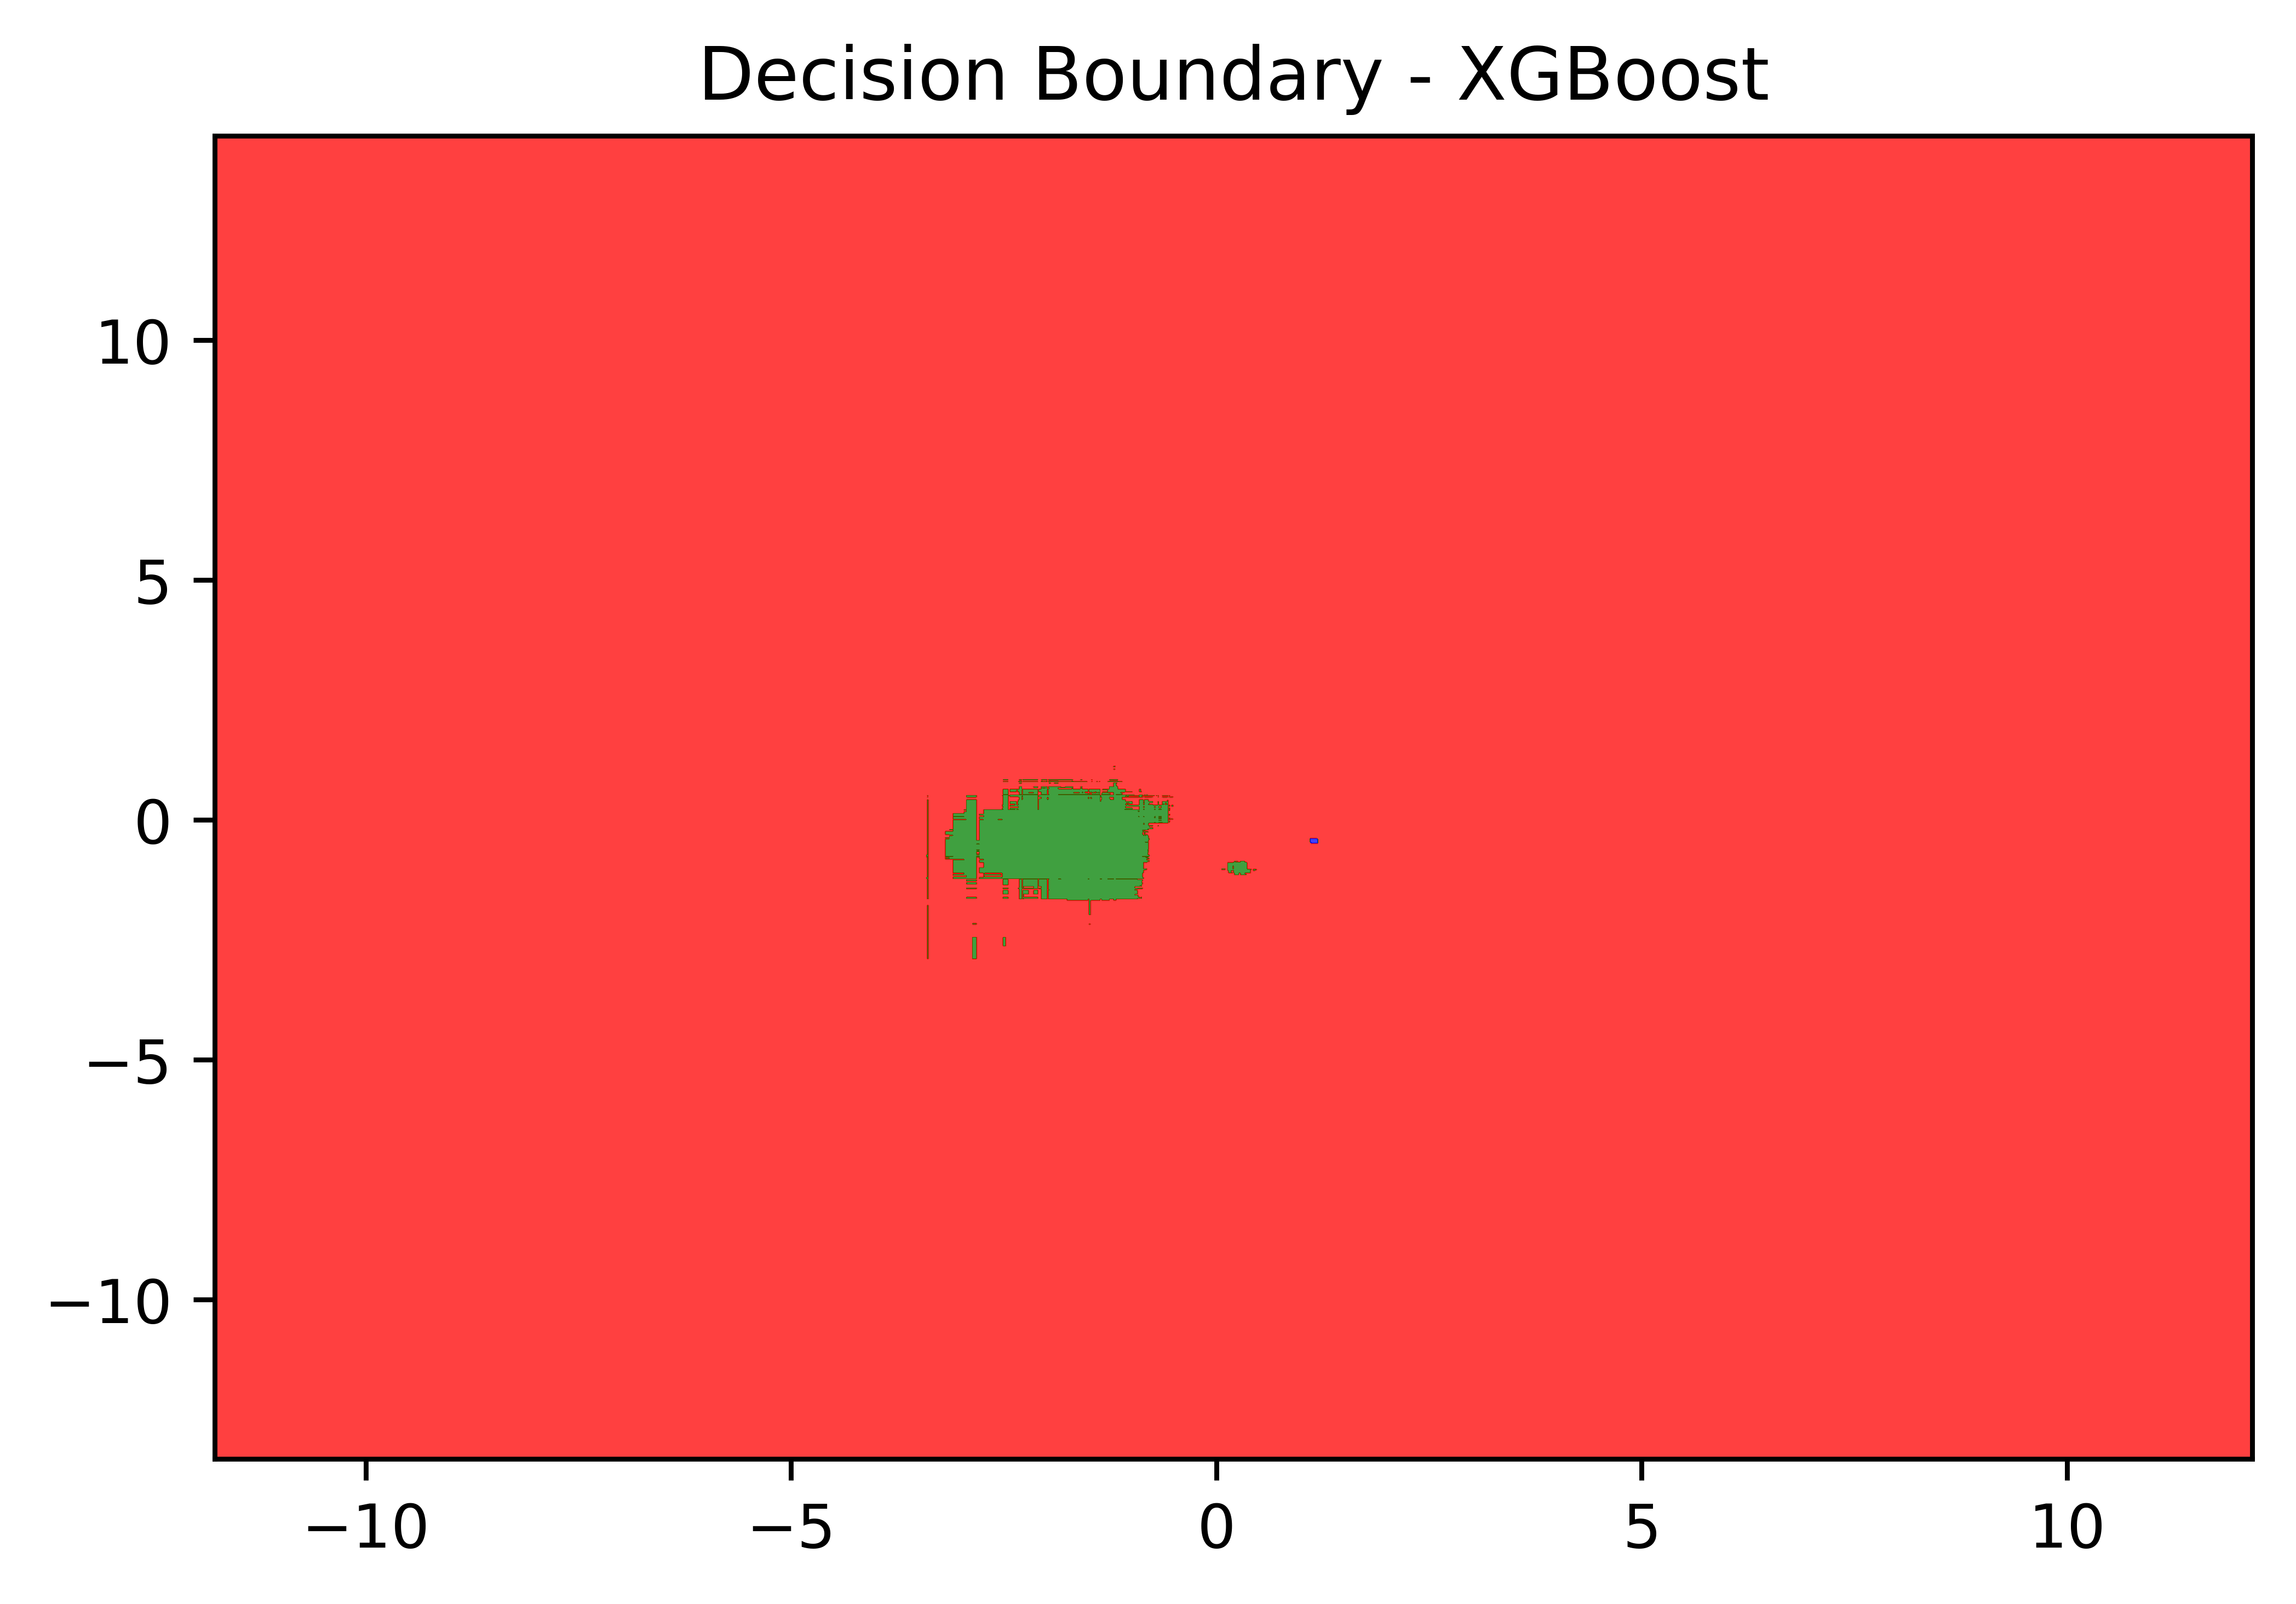

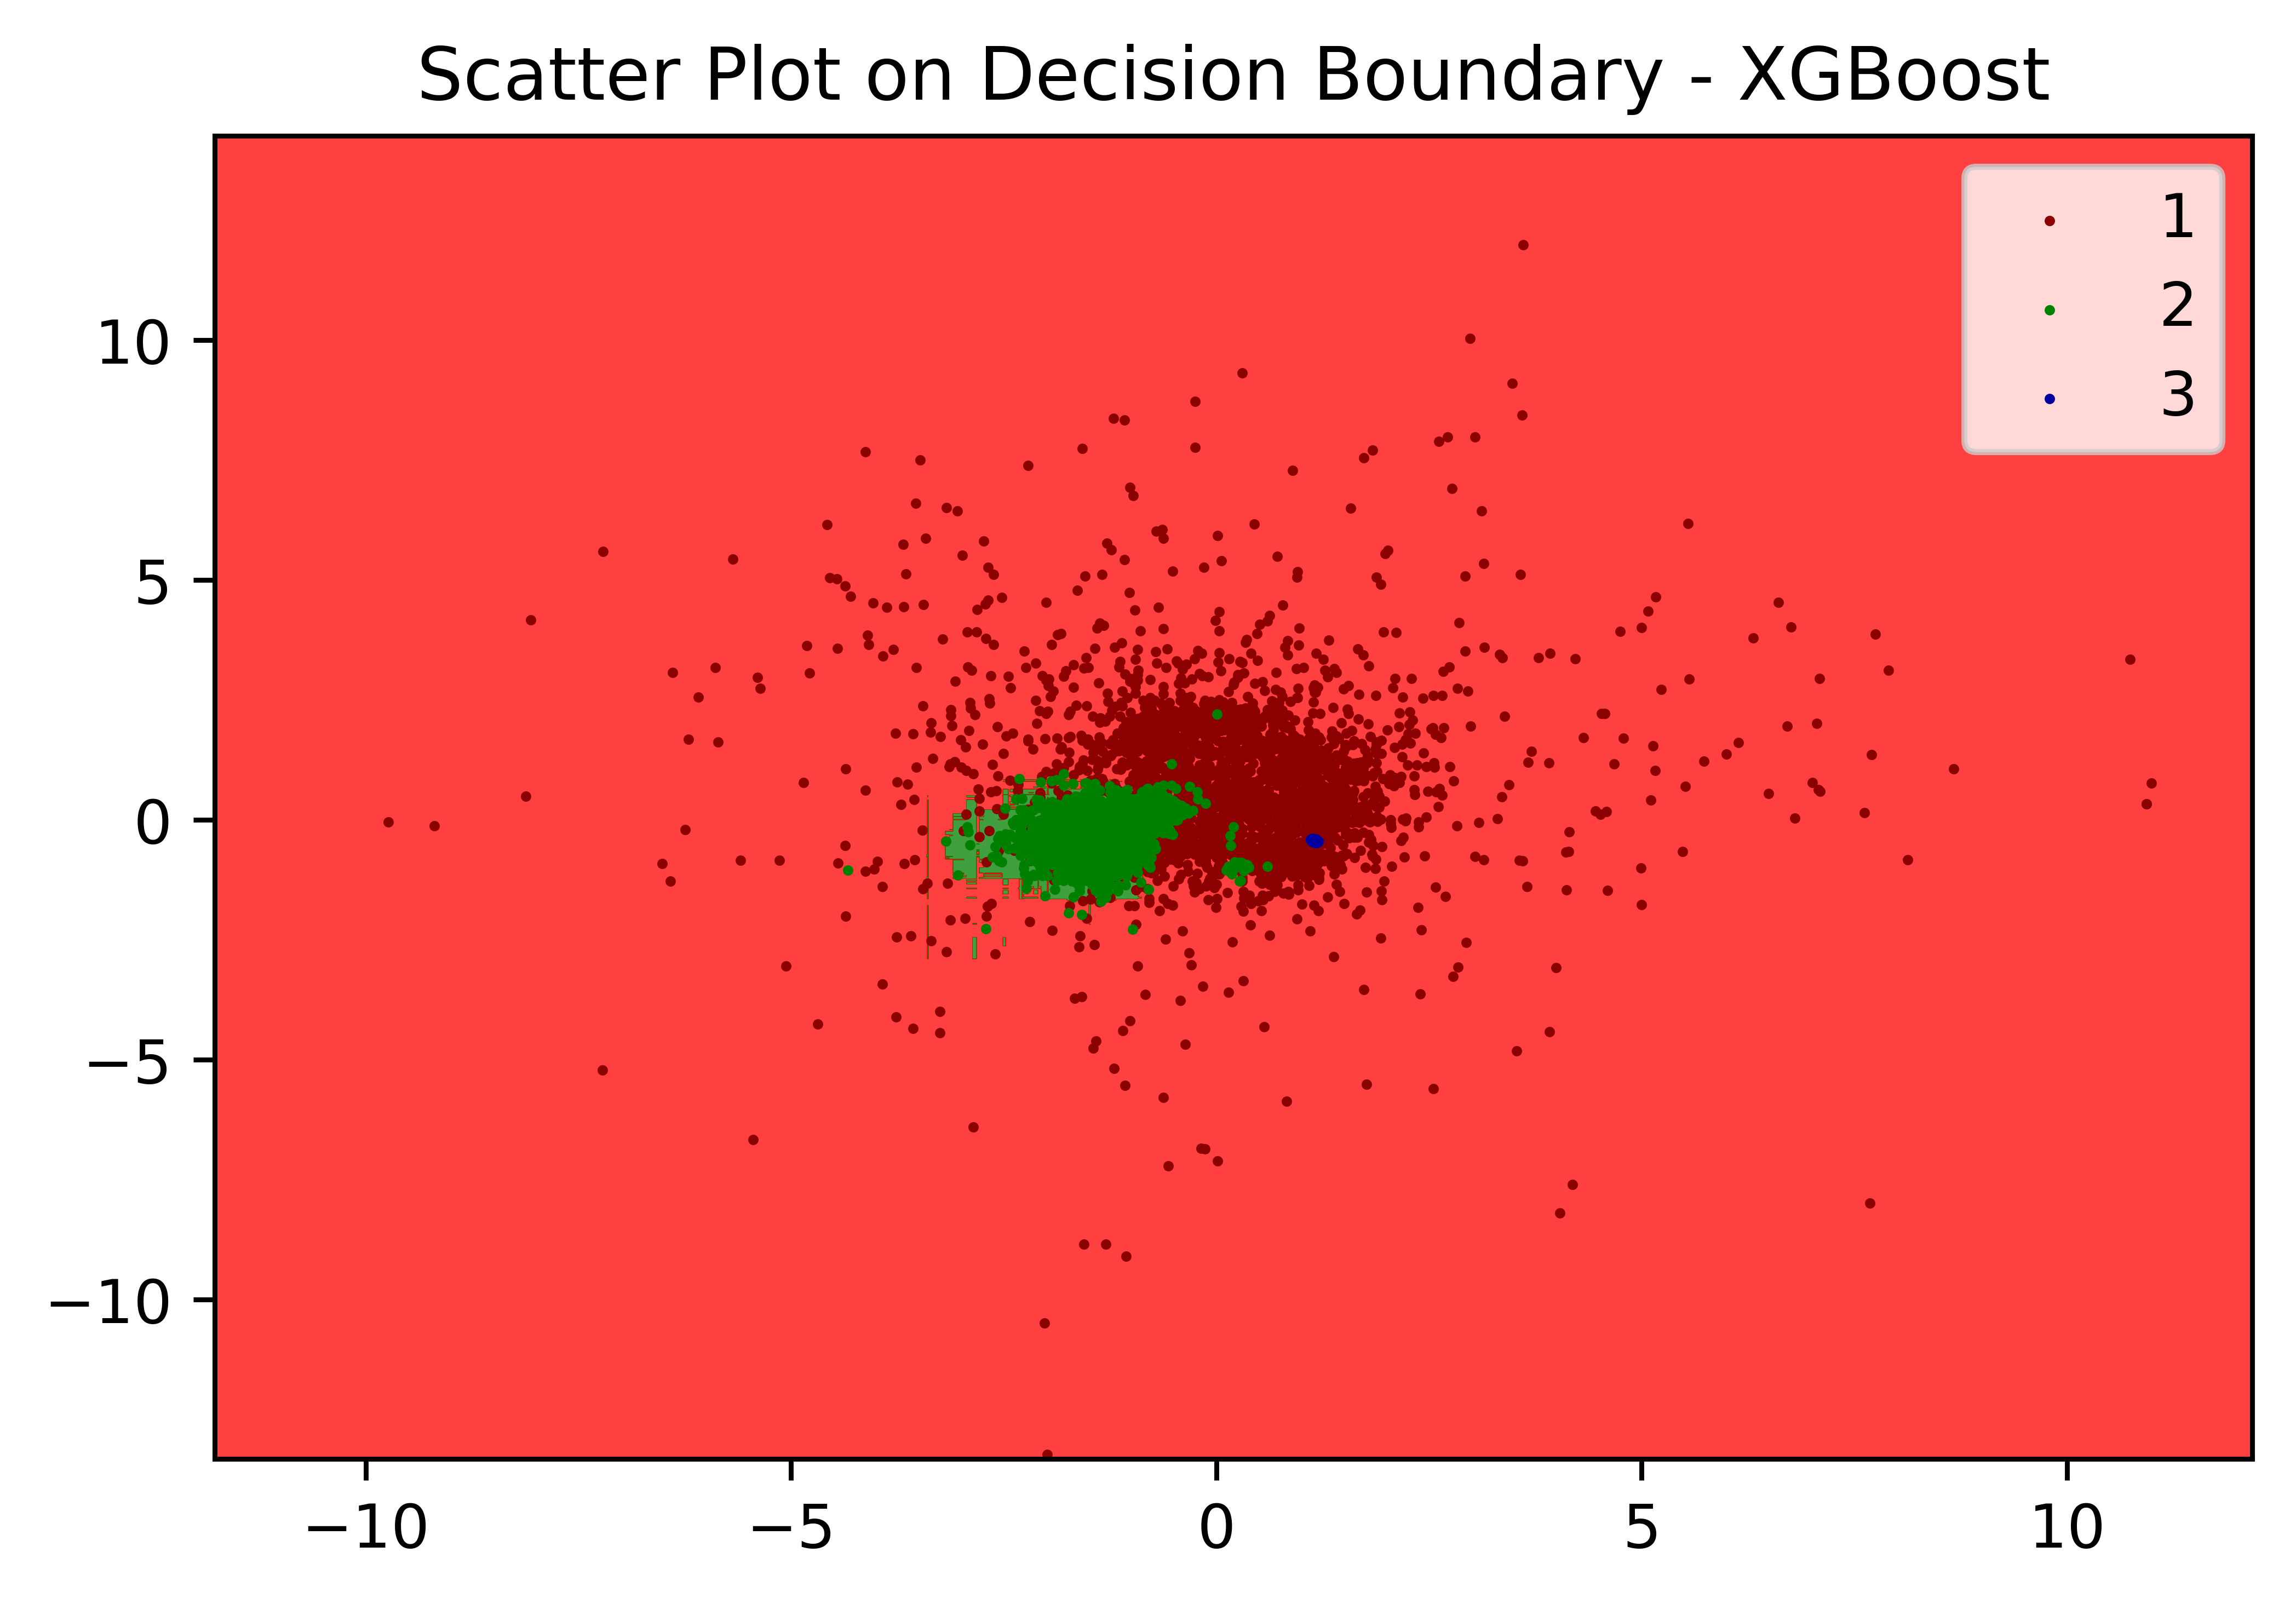

In [43]:
LDA_Plot(z_train, y_train, z_test, y_test, func = classifier_z.predict ,title = "XGBoost")

## Validation

In [42]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

accuracies_k = []
accuracies_xg = []

for i in range(5):
    x_v = sc.transform(pd.read_csv("Validation_Set/" + str(i+1) + "f_v.csv", header=None).iloc[:,1:].values)
    
    y_pred = classifier_k.predict(x_v)
    accuracies_k.append( (sum(y_pred == 1)/len(y_pred))*100 )
    
    y_pred = classifier_xg.predict(x_v)
    accuracies_xg.append( (sum(y_pred == 1)/len(y_pred))*100 )

x_v = sc.transform(pd.read_csv("Validation_Set/nf_v.csv", header=None).iloc[:,1:].values)

y_pred = classifier_k.predict(x_v)
accuracies_k.append( (sum(y_pred == 2)/len(y_pred))*100 )

y_pred = classifier_xg.predict(x_v)
accuracies_xg.append( (sum(y_pred == 2)/len(y_pred))*100 )

print("Accuarcy of KNN on Validation Set: " , sum(accuracies_k)/len(accuracies_k), "%")
print("Accuarcy of XGBoost on Validation Set: " , sum(accuracies_xg)/len(accuracies_xg), "%")

Accuarcy of KNN on Validation Set:  96.08230563457666 %
Accuarcy of XGBoost on Validation Set:  98.13518338201884 %


## Testing on Live Data

In [18]:
def Call(GSMPort):
    print("Calling Hospital")
    
    GSMPort.write(b'ATZ\r')
    time.sleep(0.5)
    
    winsound.Beep(800,500)
    
    GSMPort.write(b'AT+CMGF=1\r')
    time.sleep(0.5)
    
    GSMPort.write(b'ATD+918919029787;\r')
    time.sleep(20)
    
    GSMPort.write(b'ATH\r')
    time.sleep(0.5)

    GSMPort.write(chr(26))
    time.sleep(0.5)
    
    GSMPort.close()

In [21]:
bandPort.close()
GSMPort.close()

In [20]:
import winsound
import serial, time

bandPort = serial.Serial(port = "COM5", baudrate=9600, timeout=0.1, stopbits=serial.STOPBITS_ONE)

x_inp = []
FALL_THRES = 100

while(1):
    if(bandPort.in_waiting > 0):
        try:
            serialString = bandPort.readline().strip().decode("utf-8")
            inp = serialString.split(",")
            inp = list(map(int, inp))[1:]
            #inp = np.asarray(list(map(int, inp))[1:])
            #print(inp)
            
            if(len(inp) == 6 and len(x_inp) < FALL_THRES):
                x_inp.append(inp)
                
            elif(len(x_inp) >= FALL_THRES): 
                y_pred = classifier_xg.predict(sc.transform(np.asarray(x_inp)))
                out = np.bincount(y_pred).argmax()
                if (out == 1):
                    GSMPort = serial.Serial("COM4" , 9600 , timeout = .1)#Port of GSM Module
                    print("Its a Fall")
                    Call(GSMPort)
                elif(out == 2):
                    print("Its a non-Fall")
                elif(out == 3):
                    print("At Rest")
                bandPort.flush()
                x_inp = []
                continue
                
            else:
                continue
                
        except Exception:
            continue   

Its a Fall
Calling Hospital


KeyboardInterrupt: 